# Metacognition Metrics from Rahnev (2025) — Implementation and Applicability

This notebook implements the **17 measures of metacognition** assessed in:

> Rahnev, D. (2025). *A comprehensive assessment of current methods for measuring metacognition.*
> Nature Communications. https://doi.org/10.1038/s41467-025-56117-0

and evaluates which of them can be validly applied to this study's data. It is a companion to
`deep_analysis_notebook.ipynb` (same folder); the measure-by-measure verdicts are written up in
[`METACOGNITION_METRICS_RATIONALE.md`](METACOGNITION_METRICS_RATIONALE.md).

## The 17 measures

| # | Measure | Family |
|---|---|---|
| 1 | ΔConf (mean confidence correct − incorrect) | Traditional type-2 |
| 2 | AUC2 (area under the type-2 ROC) | Traditional type-2 |
| 3 | Gamma (Goodman–Kruskal) | Traditional type-2 |
| 4 | Phi (accuracy–confidence correlation) | Traditional type-2 |
| 5 | meta-d′ | SDT (meta-d′ family) |
| 6 | M-Ratio (meta-d′ / d′) | SDT (meta-d′ family) |
| 7 | M-Diff (meta-d′ − d′) | SDT (meta-d′ family) |
| 8–11 | ΔConf-Ratio, AUC2-Ratio, Gamma-Ratio, Phi-Ratio | SDT-normalized (observed / SDT-expected) |
| 12–15 | ΔConf-Diff, AUC2-Diff, Gamma-Diff, Phi-Diff | SDT-normalized (observed − SDT-expected) |
| 16 | meta-noise (σₘ) | Process model |
| 17 | meta-uncertainty | Process model (CASANDRE) |

## What this notebook does

1. **Implements** the measures as reusable functions (Part 2). The four traditional type-2
   measures run directly on trial data. The SDT-based measures (5–15) additionally need a
   two-stimulus-class detection/discrimination structure, so they are implemented for the
   standard 2AFC-with-confidence setting and **validated on simulated SDT observers** —
   including a reproduction of the paper's central result that traditional measures depend on
   type-1 task performance while Ratio measures do not. meta-noise is implemented in a
   simplified Gaussian form; meta-uncertainty is documented but not fit (see rationale).
2. **Gates applicability** against this study's data structure (Part 3): 12 four-option
   logic problems per participant, a 0–100 confidence slider, binary correctness, and *no*
   stimulus-class structure — which rules the SDT family out for these data.
3. **Applies the applicable measures** (ΔConf, AUC2, Gamma, Phi) per participant, compares
   conditions with the same statistical conventions as the main analysis notebook, and adds the
   Rahnev-motivated **type-1-performance adjustment**: because conditions differ in accuracy,
   unadjusted type-2 comparisons are partially confounded, so condition effects are re-estimated
   with actual score as a covariate — the regression analogue of the paper's Ratio measures.

Run Part 1 and Part 2 top to bottom; Part 3 modules are then self-contained.

## Part 1 — Setup and data

### 1. Imports and constants

In [1]:
from __future__ import annotations

import json
import math
import re
from pathlib import Path
from typing import Any, Callable

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from scipy import stats
from scipy.optimize import minimize
from scipy.stats import norm

DATA_DIR = Path("../../results/data/final_data")

CONDITIONS = ["ai", "ai-reliability", "alternatives", "pause-points", "reflection-task"]
BASELINE = "ai"
CONDITION_LABELS = {
    "ai": "AI (baseline)", "ai-reliability": "Reliability cards", "alternatives": "Alternatives",
    "pause-points": "Pause points", "reflection-task": "Reflection task",
}
TICK_LABELS = {
    "ai": "AI\n(baseline)", "ai-reliability": "Reliability\ncards", "alternatives": "Alterna-\ntives",
    "pause-points": "Pause\npoints", "reflection-task": "Reflection\ntask",
}
# Colorblind-safe categorical palette (validated adjacent-pair CVD dE >= 8).
CONDITION_COLORS = {
    "ai": "#2a78d6", "ai-reliability": "#eb6834", "alternatives": "#1baf7a",
    "pause-points": "#eda100", "reflection-task": "#e87ba4",
}
MEASURE_COLORS = ["#2a78d6", "#eb6834", "#1baf7a", "#eda100"]  # first four palette slots

# Canonical correct answers in authored task order (customizations/questions/correct_answers.py).
CORRECT_ANSWERS = [
    "Neither of the two statements is correct.", "Only statement 2 is correct.",
    "Only statement 1 is correct.", "Only statement 1 is correct.",
    "Neither of the two statements is correct.", "Both statements are correct.",
    "Only statement 2 is correct.", "Only statement 1 is correct.",
    "Only statement 2 is correct.", "Only statement 1 is correct.",
    "Neither of the two statements is correct.", "Only statement 2 is correct.",
]

ALPHA = 0.05
EXPECTED_MAIN_TASKS = 12
MINIMUM_COMPLETION_MINUTES = 10.0
MAX_ATTENTION_FAILURES = 1
RNG_SEED = 11

plt.rcParams.update({
    "figure.dpi": 110, "figure.facecolor": "white", "axes.facecolor": "white",
    "axes.edgecolor": "#c8c8c4", "axes.labelcolor": "#33322e", "axes.titlecolor": "#33322e",
    "axes.grid": True, "grid.color": "#eceae6", "grid.linewidth": 0.8, "axes.axisbelow": True,
    "xtick.color": "#6f6d66", "ytick.color": "#6f6d66", "text.color": "#33322e",
    "font.size": 10, "axes.spines.top": False, "axes.spines.right": False,
})


def style_ax(ax: plt.Axes) -> None:
    ax.grid(axis="x", visible=False)
    ax.tick_params(length=0)

### 2. Load the trial-level data

A compact loader that reproduces the main notebook's conventions (canonical answer key, backend
`answerResults` as the source of the 12 scored task IDs, the same four attention checks, and the
same exclusion rules). The result is one row per participant × problem with binary correctness
and 0–100 confidence.

In [2]:
def norm_text(value: Any) -> str:
    return re.sub(r"\s+", " ", str(value or "")).strip().casefold()


def number(value: Any) -> float:
    try:
        return float(value)
    except (TypeError, ValueError):
        return math.nan


def main_task_ids(record: dict[str, Any]) -> list[int]:
    results = record.get("answerResults") or {}
    ids = sorted({int(k.split(".")[0]) for k in results if re.fullmatch(r"\d+\.\d+", k)})
    if len(ids) == EXPECTED_MAIN_TASKS:
        return ids
    titled = sorted(tid for tid, t in ((int(k), v) for k, v in record["tasks"].items())
                    if str(t.get("title") or "").startswith("Scenario:"))
    if titled:
        return titled[-EXPECTED_MAIN_TASKS:]
    with_conf = [int(k) for k, t in record["tasks"].items()
                 if "confident" in norm_text(((t.get("responses") or {})
                                              .get(f"{k}.2", {}) or {}).get("question"))]
    return sorted(with_conf)[-EXPECTED_MAIN_TASKS:]


def attention_failures(record: dict[str, Any]) -> int:
    passed = found = 0
    for key, task in record["tasks"].items():
        for rkey, resp in (task.get("responses") or {}).items():
            if not isinstance(resp, dict):
                continue
            q, a = norm_text(resp.get("question")), resp.get("answer")
            if "what type of tasks will you be working on" in q:
                found += 1; passed += norm_text(a) == "planning and organizing"
            elif "second tab" in q and "which letter" in q:
                found += 1; passed += str(a).strip().upper() == "C"
            elif "reading this" in q and "enter the number 5" in q:
                found += 1; passed += str(a).strip() == "5"
            elif "reading this" in q and "highest possible value" in q:
                found += 1; passed += number(a) == 5
    return found - passed


def completion_minutes(record: dict[str, Any]) -> float:
    times = [number(t.get("ts")) for t in record["tasks"].values()]
    times = [t / 1000 if t > 10_000_000_000 else t for t in times if math.isfinite(t)]
    return (max(times) - min(times)) / 60 if len(times) >= 2 else math.nan


trial_rows = []
for condition in CONDITIONS:
    data = json.loads((DATA_DIR / f"{condition.replace('-', '_')}.json").read_text("utf-8-sig"))
    for rec in data["participants"]:
        pid = str(rec["participantId"])
        ids = main_task_ids(rec)
        assert len(ids) == EXPECTED_MAIN_TASKS, pid
        answered = 0
        rows = []
        for trial, (tid, expected) in enumerate(zip(ids, CORRECT_ANSWERS), 1):
            resp = rec["tasks"].get(str(tid), {}).get("responses") or {}
            answer = (resp.get(f"{tid}.1") or {}).get("answer")
            confidence = number((resp.get(f"{tid}.2") or {}).get("answer"))
            answered += answer is not None
            rows.append({
                "participant_id": pid, "condition": condition, "trial": trial,
                "correct": float(norm_text(answer) == norm_text(expected)) if answer is not None else math.nan,
                "confidence": confidence,
            })
        excluded = (attention_failures(rec) > MAX_ATTENTION_FAILURES
                    or answered < EXPECTED_MAIN_TASKS
                    or completion_minutes(rec) < MINIMUM_COMPLETION_MINUTES)
        for row in rows:
            row["excluded"] = excluded
        trial_rows.extend(rows)

trials = pd.DataFrame(trial_rows)
trials["condition"] = pd.Categorical(trials["condition"], categories=CONDITIONS, ordered=True)
eligible_trials = trials[~trials["excluded"]].copy()
n_participants = trials["participant_id"].nunique()
n_eligible = eligible_trials["participant_id"].nunique()
print(f"{n_participants} participants loaded, {n_eligible} in the analysis sample "
      f"({len(eligible_trials)} trials) — must match the main notebook (917).")
assert n_eligible == 917, "analysis sample differs from deep_analysis_notebook.ipynb"

925 participants loaded, 917 in the analysis sample (11004 trials) — must match the main notebook (917).


In [3]:
# Properties of the data that decide measure applicability (referenced throughout).
accuracy = eligible_trials.groupby("participant_id", observed=True)["correct"].mean()
data_properties = pd.Series({
    "trials per participant": 12,
    "response format": "4-option multiple choice (chance = 25%)",
    "stimulus classes for SDT (S1/S2)": "none - logic problems, no signal/noise design",
    "confidence scale": "0-100 slider (quasi-continuous)",
    "participants with 0% or 100% accuracy": int(((accuracy == 0) | (accuracy == 1)).sum()),
    "mean accuracy (analysis sample)": f"{accuracy.mean():.1%}",
    "sessions per participant": "1 (no test-retest possible)",
}, name="value").to_frame()
display(data_properties)

,value
trials per participant,12
response format,4-option multiple choice (chance = 25%)
stimulus classes for SDT (S1/S2),"none - logic problems, no signal/noise design"
confidence scale,0-100 slider (quasi-continuous)
participants with 0% or 100% accuracy,0
mean accuracy (analysis sample),43.3%
sessions per participant,1 (no test-retest possible)


## Part 2 — Measure implementations

### 3. Traditional type-2 measures (ΔConf, AUC2, Gamma, Phi)

These four need only per-trial correctness and confidence. All are undefined when a participant
has no correct or no incorrect trials (no variance to relate confidence to).

In [4]:
def delta_conf(correct: np.ndarray, confidence: np.ndarray) -> float:
    """Mean confidence on correct minus incorrect trials."""
    conf_correct, conf_incorrect = confidence[correct == 1], confidence[correct == 0]
    if not len(conf_correct) or not len(conf_incorrect):
        return math.nan
    return float(conf_correct.mean() - conf_incorrect.mean())


def auc2(correct: np.ndarray, confidence: np.ndarray) -> float:
    """Area under the type-2 ROC: P(conf_correct > conf_incorrect), ties counted 1/2.
    Computed as the Mann–Whitney U statistic via average ranks (O(n log n))."""
    n_correct, n_incorrect = int((correct == 1).sum()), int((correct == 0).sum())
    if not n_correct or not n_incorrect:
        return math.nan
    ranks = stats.rankdata(confidence)
    u_stat = ranks[correct == 1].sum() - n_correct * (n_correct + 1) / 2
    return float(u_stat / (n_correct * n_incorrect))


def gamma_gk(correct: np.ndarray, confidence: np.ndarray) -> float:
    """Goodman–Kruskal gamma: (concordant − discordant) / (concordant + discordant),
    counted over unique confidence values (ties excluded), O(n log n)."""
    if not (correct == 1).any() or not (correct == 0).any():
        return math.nan
    _, inverse = np.unique(confidence, return_inverse=True)
    n_levels = inverse.max() + 1
    count_correct = np.bincount(inverse[correct == 1], minlength=n_levels)
    count_incorrect = np.bincount(inverse[correct == 0], minlength=n_levels)
    incorrect_below = np.concatenate(([0], np.cumsum(count_incorrect)[:-1]))
    incorrect_above = count_incorrect.sum() - np.cumsum(count_incorrect)
    concordant = float((count_correct * incorrect_below).sum())
    discordant = float((count_correct * incorrect_above).sum())
    if concordant + discordant == 0:
        return math.nan
    return (concordant - discordant) / (concordant + discordant)


def phi_coef(correct: np.ndarray, confidence: np.ndarray) -> float:
    """Pearson correlation between accuracy (0/1) and confidence."""
    if correct.std() == 0 or confidence.std() == 0:
        return math.nan
    return float(np.corrcoef(correct, confidence)[0, 1])


TRADITIONAL: dict[str, Callable[[np.ndarray, np.ndarray], float]] = {
    "delta_conf": delta_conf, "auc2": auc2, "gamma": gamma_gk, "phi": phi_coef,
}
MEASURE_LABELS = {"delta_conf": "ΔConf", "auc2": "AUC2", "gamma": "Gamma", "phi": "Phi"}

# Quick sanity checks on toy data.
toy_correct = np.array([1, 1, 1, 0, 0, 0], float)
assert auc2(toy_correct, np.array([90, 80, 70, 30, 20, 10], float)) == 1.0
assert auc2(toy_correct, np.array([10, 20, 30, 70, 80, 90], float)) == 0.0
assert abs(gamma_gk(toy_correct, np.array([90, 10, 50, 50, 10, 90], float))) < 1e-12
assert delta_conf(toy_correct, np.array([80, 80, 80, 60, 60, 60], float)) == 20
print("traditional measures: sanity checks passed")

traditional measures: sanity checks passed


### 4. The SDT machinery: meta-d′ family and SDT-normalized Ratio/Diff variants

Measures 5–15 presuppose the standard signal-detection setting: **two stimulus classes**
(S1/S2), a binary type-1 response, and confidence ratings. meta-d′ (Maniscalco & Lau, 2012) is
the type-1 sensitivity that an SDT-ideal observer would need to produce the observed
response-conditional confidence distributions; M-Ratio = meta-d′/d′ and M-Diff = meta-d′ − d′
normalize it by actual sensitivity. Rahnev (2025) extends the same normalization logic to the
traditional measures: each is computed once on the observed data and once as its **expectation
for an SDT-ideal observer with the observed d′, criterion, and confidence-criterion placement**,
then combined as observed/expected (Ratio) or observed − expected (Diff).

The functions below implement this for 2AFC data with binned confidence; Section 5 validates
them on simulated observers. They cannot run on this study's data (no stimulus classes — see
the Part 3 applicability gate), which is exactly the point they document.

In [5]:
EPS = 1e-10


def type1_sdt(stimulus: np.ndarray, response: np.ndarray) -> tuple[float, float]:
    """d' and criterion c from binary stimulus/response arrays (rate padding 0.5/(n+1))."""
    n_s2, n_s1 = (stimulus == 1).sum(), (stimulus == 0).sum()
    hit_rate = ((response[stimulus == 1] == 1).sum() + 0.5) / (n_s2 + 1)
    fa_rate = ((response[stimulus == 0] == 1).sum() + 0.5) / (n_s1 + 1)
    d1 = norm.ppf(hit_rate) - norm.ppf(fa_rate)
    c1 = -0.5 * (norm.ppf(hit_rate) + norm.ppf(fa_rate))
    return float(d1), float(c1)


def _conf_counts(stimulus, response, conf_bin, n_bins):
    """counts[s][r][j] of confidence bins j=1..K per stimulus × response cell."""
    counts = np.zeros((2, 2, n_bins))
    for s in (0, 1):
        for r in (0, 1):
            mask = (stimulus == s) & (response == r)
            for j in range(1, n_bins + 1):
                counts[s, r, j - 1] = ((conf_bin[mask]) == j).sum()
    return counts


def fit_meta_d(stimulus: np.ndarray, response: np.ndarray, conf_bin: np.ndarray,
               n_bins: int) -> dict[str, float]:
    """MLE meta-d' (Maniscalco & Lau 2012): fit an SDT observer whose type-1 sensitivity is
    meta_d (criterion scaled as c' = c * meta_d / d') to the response-conditional confidence
    distributions. conf_bin must be integers 1..n_bins."""
    d1, c1 = type1_sdt(stimulus, response)
    counts = _conf_counts(stimulus, response, conf_bin, n_bins)

    def nll(theta):
        meta_d = theta[0]
        c_prime = c1 * meta_d / d1 if d1 != 0 else c1
        upper = c_prime + np.cumsum(np.exp(theta[1:n_bins]))          # type-2 criteria, R=1 side
        lower = c_prime - np.cumsum(np.exp(theta[n_bins:]))           # type-2 criteria, R=0 side
        total = 0.0
        for s, mu in ((0, -meta_d / 2), (1, meta_d / 2)):
            # response = 1: evidence above c'; bins split by ascending criteria
            edges_hi = np.concatenate(([c_prime], upper, [np.inf]))
            p_bins_1 = norm.cdf(edges_hi[1:] - mu) - norm.cdf(edges_hi[:-1] - mu)
            p_r1 = max(1 - norm.cdf(c_prime - mu), EPS)
            total -= np.sum(counts[s, 1] * np.log(np.maximum(p_bins_1 / p_r1, EPS)))
            # response = 0: evidence below c'; bins split by descending criteria
            edges_lo = np.concatenate(([c_prime], lower, [-np.inf]))
            p_bins_0 = norm.cdf(edges_lo[:-1] - mu) - norm.cdf(edges_lo[1:] - mu)
            p_r0 = max(norm.cdf(c_prime - mu), EPS)
            total -= np.sum(counts[s, 0] * np.log(np.maximum(p_bins_0 / p_r0, EPS)))
        return total

    init = np.concatenate(([d1], np.log(np.full(n_bins - 1, 0.4)), np.log(np.full(n_bins - 1, 0.4))))
    fit = minimize(nll, init, method="Nelder-Mead",
                   options={"maxiter": 8000, "xatol": 1e-4, "fatol": 1e-4})
    meta_d = float(fit.x[0])
    return {"d1": d1, "c1": c1, "meta_d": meta_d,
            "m_ratio": meta_d / d1 if d1 != 0 else math.nan, "m_diff": meta_d - d1}


def sdt_expected_traditional(d1: float, c1: float, observed_bin_props: np.ndarray,
                             n_bins: int, n_sim: int = 400_000,
                             seed: int = RNG_SEED) -> dict[str, float]:
    """Expected ΔConf/AUC2/Gamma/Phi for an SDT-IDEAL observer with the observed d', c, and
    confidence criteria placed to reproduce the observed marginal confidence-bin proportions."""
    rng = np.random.default_rng(seed)
    stimulus = rng.integers(0, 2, n_sim)
    evidence = rng.normal((stimulus - 0.5) * d1, 1.0)
    response = (evidence > c1).astype(float)
    distance = np.abs(evidence - c1)
    # place shared type-2 criteria at the distance quantiles matching observed bin proportions
    cum = np.cumsum(observed_bin_props)[:-1]
    thresholds = np.quantile(distance, cum)
    conf = np.digitize(distance, thresholds) + 1.0
    correct = (response == stimulus).astype(float)
    return {name: fn(correct, conf) for name, fn in TRADITIONAL.items()}


def rahnev_ratio_diff(observed: dict[str, float], expected: dict[str, float]) -> dict[str, float]:
    """The paper's eight SDT-normalized variants."""
    out = {}
    for name in TRADITIONAL:
        out[f"{name}_ratio"] = (observed[name] / expected[name]
                                if expected.get(name) not in (0, None) else math.nan)
        out[f"{name}_diff"] = observed[name] - expected[name]
    return out


def sigma_meta_from_mratio(m_ratio: float) -> float:
    """Simplified Gaussian meta-noise: confidence evidence = decision evidence + N(0, σₘ),
    which attenuates meta-d' to ≈ d'/sqrt(1+σₘ²), so σₘ = sqrt(1/M-Ratio² − 1).
    This is a reduced form of Shekhar & Rahnev's (2021) meta-noise measure — see the rationale
    document for why the full lognormal model is not identifiable from this study's data."""
    if not math.isfinite(m_ratio) or m_ratio <= 0:
        return math.nan
    return math.sqrt(max(0.0, 1.0 / m_ratio**2 - 1.0))


def meta_uncertainty(*_args, **_kwargs):
    """Measure 17 (CASANDRE; Boundy-Singer et al. 2022) models confidence as a probability
    computed under uncertainty about one's own sensory noise. Fitting it requires a stimulus
    design with graded evidence strengths/reliabilities and many trials per level — neither
    exists in this study (12 four-option logic problems, no stimulus-strength manipulation)."""
    raise NotImplementedError(meta_uncertainty.__doc__)


print("SDT machinery defined (meta-d', M-Ratio, M-Diff, 8 Ratio/Diff variants, "
      "simplified meta-noise, meta-uncertainty stub)")

SDT machinery defined (meta-d', M-Ratio, M-Diff, 8 Ratio/Diff variants, simplified meta-noise, meta-uncertainty stub)


### 5. Validation on simulated SDT observers

A simulated observer with known ground truth: decision evidence x ~ N(±d′/2, 1), response by
criterion c, and confidence computed from x plus **metacognitive noise** σₘ (σₘ = 0 → ideal
observer whose meta-d′ must equal d′ and whose Ratio variants must equal 1).

In [6]:
def simulate_observer(d_prime: float, criterion: float, sigma_m: float, n_trials: int,
                      n_bins: int, rng: np.random.Generator):
    stimulus = rng.integers(0, 2, n_trials)
    evidence = rng.normal((stimulus - 0.5) * d_prime, 1.0)
    response = (evidence > criterion).astype(float)
    conf_evidence = evidence + rng.normal(0, sigma_m, n_trials)
    distance = np.abs(conf_evidence - criterion)
    thresholds = np.quantile(distance, np.linspace(0, 1, n_bins + 1)[1:-1])
    conf_bin = (np.digitize(distance, thresholds) + 1).astype(float)
    correct = (response == stimulus).astype(float)
    return stimulus, response, conf_bin, correct


rng = np.random.default_rng(RNG_SEED)
N_BINS = 4

# 5a. Ideal observer: meta-d' must recover d', M-Ratio ≈ 1, Ratio variants ≈ 1, Diff ≈ 0.
stim, resp, conf_bin, correct = simulate_observer(1.5, 0.1, 0.0, 100_000, N_BINS, rng)
fit = fit_meta_d(stim, resp, conf_bin, N_BINS)
observed = {name: fn(correct, conf_bin) for name, fn in TRADITIONAL.items()}
bin_props = np.array([(conf_bin == j).mean() for j in range(1, N_BINS + 1)])
expected = sdt_expected_traditional(fit["d1"], fit["c1"], bin_props, N_BINS)
variants = rahnev_ratio_diff(observed, expected)
print(f"ideal observer (d'=1.5): meta-d' = {fit['meta_d']:.3f} (target {fit['d1']:.3f}), "
      f"M-Ratio = {fit['m_ratio']:.3f} (target 1)")
for name in TRADITIONAL:
    print(f"  {MEASURE_LABELS[name]:6s} observed {observed[name]:7.3f}  "
          f"ratio {variants[f'{name}_ratio']:6.3f} (target 1)  "
          f"diff {variants[f'{name}_diff']:+7.3f} (target 0)")
assert abs(fit["m_ratio"] - 1) < 0.05, "meta-d' implementation failed ideal-observer recovery"
assert all(abs(variants[f"{n}_ratio"] - 1) < 0.05 for n in TRADITIONAL)
print("validation passed: implementations recover the ideal observer")

ideal observer (d'=1.5): meta-d' = 1.501 (target 1.494), M-Ratio = 1.005 (target 1)
  ΔConf  observed   0.875  ratio  0.999 (target 1)  diff  -0.001 (target 0)
  AUC2   observed   0.719  ratio  1.000 (target 1)  diff  -0.000 (target 0)
  Gamma  observed   0.563  ratio  0.999 (target 1)  diff  -0.000 (target 0)
  Phi    observed   0.329  ratio  0.998 (target 1)  diff  -0.001 (target 0)
validation passed: implementations recover the ideal observer


In [7]:
# 5b. Metacognitive-noise sweep: efficiency measures must fall as σₘ rises. The simplified
# Gaussian meta-noise estimator recovers the ORDERING of σₘ but inflates its magnitude
# (the meta-d' ≈ d'/sqrt(1+σₘ²) attenuation approximation is crude for binned,
# criterion-based confidence), so treat it as ordinal — one more reason the full
# process-model measures are left to purpose-built designs.
sweep_rows = []
for sigma_m in (0.0, 0.25, 0.5, 1.0, 1.5):
    stim, resp, conf_bin, correct = simulate_observer(1.5, 0.1, sigma_m, 100_000, N_BINS, rng)
    fit = fit_meta_d(stim, resp, conf_bin, N_BINS)
    sweep_rows.append({"sigma_m_true": sigma_m, "meta_d": round(fit["meta_d"], 3),
                       "m_ratio": round(fit["m_ratio"], 3),
                       "m_diff": round(fit["m_diff"], 3),
                       "sigma_m_recovered": round(sigma_meta_from_mratio(fit["m_ratio"]), 3),
                       "auc2_observed": round(auc2(correct, conf_bin), 3)})
display(pd.DataFrame(sweep_rows).style.hide(axis="index"))

sigma_m_true,meta_d,m_ratio,m_diff,sigma_m_recovered,auc2_observed
0.000000,1.515000,1.009000,0.013000,0.000000,0.721000
0.250000,1.413000,0.943000,-0.086000,0.354000,0.707000
0.500000,1.140000,0.751000,-0.377000,0.878000,0.667000
1.000000,0.663000,0.441000,-0.839000,2.034000,0.597000
1.500000,0.412000,0.274000,-1.091000,3.510000,0.560000


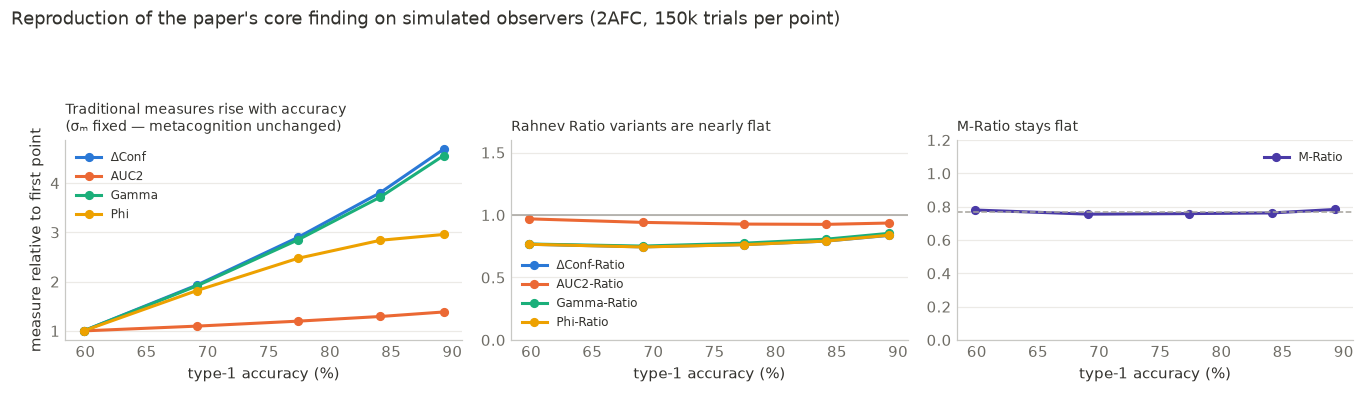

In [8]:
# 5c. The paper's central problem, reproduced: hold metacognitive efficiency FIXED (σₘ = 0.5)
# and vary type-1 performance. Traditional measures track d' even though metacognition never
# changes; the Ratio variants and M-Ratio stay flat. This is why cross-group comparisons on
# traditional measures are confounded when the groups differ in accuracy — as this study's
# conditions do.
d_grid = np.array([0.5, 1.0, 1.5, 2.0, 2.5])
perf_rows = []
for d_true in d_grid:
    stim, resp, conf_bin, correct = simulate_observer(d_true, 0.1, 0.5, 150_000, N_BINS, rng)
    fit = fit_meta_d(stim, resp, conf_bin, N_BINS)
    observed = {name: fn(correct, conf_bin) for name, fn in TRADITIONAL.items()}
    bin_props = np.array([(conf_bin == j).mean() for j in range(1, N_BINS + 1)])
    expected = sdt_expected_traditional(fit["d1"], fit["c1"], bin_props, N_BINS)
    variants = rahnev_ratio_diff(observed, expected)
    perf_rows.append({"d_true": d_true, "accuracy": correct.mean(), "m_ratio": fit["m_ratio"],
                      **observed,
                      **{f"{name}_ratio": variants[f"{name}_ratio"] for name in TRADITIONAL}})
perf = pd.DataFrame(perf_rows)

fig, axes = plt.subplots(1, 3, figsize=(12.5, 3.6))
for i, name in enumerate(TRADITIONAL):
    scale = perf[name] / perf[name].iloc[0]           # normalize to the d'=0.5 point
    axes[0].plot(perf["accuracy"] * 100, scale, marker="o", markersize=5,
                 color=MEASURE_COLORS[i], linewidth=2, label=MEASURE_LABELS[name])
axes[0].set_title("Traditional measures rise with accuracy\n(σₘ fixed — metacognition unchanged)",
                  fontsize=9, loc="left")
axes[0].set_ylabel("measure relative to first point")
for i, name in enumerate(TRADITIONAL):
    axes[1].plot(perf["accuracy"] * 100, perf[f"{name}_ratio"], marker="o", markersize=5,
                 color=MEASURE_COLORS[i], linewidth=2, label=f"{MEASURE_LABELS[name]}-Ratio")
axes[1].axhline(1, color="#a5a39d", linewidth=1)
axes[1].set_title("Rahnev Ratio variants are nearly flat", fontsize=9, loc="left")
axes[1].set_ylim(0, 1.6)
axes[2].plot(perf["accuracy"] * 100, perf["m_ratio"], marker="o", markersize=5,
             color="#4a3aa7", linewidth=2, label="M-Ratio")
axes[2].axhline(perf["m_ratio"].mean(), color="#a5a39d", linewidth=1, linestyle="--")
axes[2].set_title("M-Ratio stays flat", fontsize=9, loc="left")
axes[2].set_ylim(0, 1.2)
for ax in axes:
    ax.set_xlabel("type-1 accuracy (%)")
    ax.legend(frameon=False, fontsize=8)
    style_ax(ax)
fig.suptitle("Reproduction of the paper's core finding on simulated observers "
             "(2AFC, 150k trials per point)", x=0.01, ha="left", fontsize=12)
fig.tight_layout(rect=(0, 0, 1, 0.88))
plt.show()

In [9]:
# 5d. Small-sample behavior at this study's trial count. With 12 trials per participant the
# traditional measures are extremely noisy at the individual level — group-level comparisons
# remain unbiased but individual scores should not be interpreted.
rows = []
rng12 = np.random.default_rng(RNG_SEED + 1)
for _ in range(4000):
    stim, resp, conf_bin, correct = simulate_observer(0.8, 0.1, 0.5, 12, N_BINS, rng12)
    rows.append({name: fn(correct, conf_bin) for name, fn in TRADITIONAL.items()})
small = pd.DataFrame(rows)
small_summary = pd.DataFrame({
    "undefined_share_%": (small.isna().mean() * 100).round(1),
    "mean (defined)": small.mean().round(3),
    "sd across simulated participants": small.std().round(3),
}).rename(index=MEASURE_LABELS)
print("4000 simulated participants, 12 trials each, identical true metacognition:")
display(small_summary)

4000 simulated participants, 12 trials each, identical true metacognition:


,undefined_share_%,mean (defined),sd across simulated participants
ΔConf,0.4,0.396,0.726
AUC2,0.4,0.599,0.182
Gamma,0.4,0.235,0.429
Phi,0.4,0.159,0.287


## Part 3 — Application to the study data

### 6. Applicability gate

Each measure's requirements checked against the data properties from Section 2. Full
reasoning per measure is in `METACOGNITION_METRICS_RATIONALE.md`.

In [10]:
GATE = [
    ("ΔConf", "use", "needs only correctness + confidence; = the study's confidence_discrimination"),
    ("AUC2", "use", "needs only correctness + confidence; robust to confidence-scale usage"),
    ("Gamma", "use with caution", "computable, but redundant with AUC2 (identical ordering info)"),
    ("Phi", "use with caution", "computable, but sensitive to confidence-scale usage and accuracy base rate"),
    ("meta-d′", "do not use", "requires S1/S2 stimulus classes and ≳100 trials; task has neither"),
    ("M-Ratio", "do not use", "inherits meta-d′ requirements; ratio unstable at low trial counts"),
    ("M-Diff", "do not use", "inherits meta-d′ requirements"),
    ("ΔConf-Ratio", "do not use", "needs the SDT-expected baseline, which needs d′/criterion"),
    ("AUC2-Ratio", "do not use", "needs the SDT-expected baseline, which needs d′/criterion"),
    ("Gamma-Ratio", "do not use", "needs the SDT-expected baseline, which needs d′/criterion"),
    ("Phi-Ratio", "do not use", "needs the SDT-expected baseline, which needs d′/criterion"),
    ("ΔConf-Diff", "do not use", "needs the SDT-expected baseline, which needs d′/criterion"),
    ("AUC2-Diff", "do not use", "needs the SDT-expected baseline, which needs d′/criterion"),
    ("Gamma-Diff", "do not use", "needs the SDT-expected baseline, which needs d′/criterion"),
    ("Phi-Diff", "do not use", "needs the SDT-expected baseline, which needs d′/criterion"),
    ("meta-noise", "do not use", "process-model fit; not identifiable from 12 MCQ trials"),
    ("meta-uncertainty", "do not use", "CASANDRE needs graded stimulus strengths and many trials"),
]
gate_table = pd.DataFrame(GATE, columns=["measure", "verdict", "why"])
counts = gate_table["verdict"].value_counts()
print(f"{counts.get('use', 0)} usable, {counts.get('use with caution', 0)} usable with caution, "
      f"{counts.get('do not use', 0)} not applicable — of 17 measures")
with pd.option_context("display.max_colwidth", 100):
    display(gate_table.style.hide(axis="index"))

# The performance-dependence problem the Ratio variants were built to solve is real in these
# data (conditions differ in accuracy), so Section 9 substitutes the regression analogue:
# condition effects on the traditional measures re-estimated with actual score as a covariate.

2 usable, 2 usable with caution, 13 not applicable — of 17 measures


measure,verdict,why
ΔConf,use,needs only correctness + confidence; = the study's confidence_discrimination
AUC2,use,needs only correctness + confidence; robust to confidence-scale usage
Gamma,use with caution,"computable, but redundant with AUC2 (identical ordering info)"
Phi,use with caution,"computable, but sensitive to confidence-scale usage and accuracy base rate"
meta-d′,do not use,requires S1/S2 stimulus classes and ≳100 trials; task has neither
M-Ratio,do not use,inherits meta-d′ requirements; ratio unstable at low trial counts
M-Diff,do not use,inherits meta-d′ requirements
ΔConf-Ratio,do not use,"needs the SDT-expected baseline, which needs d′/criterion"
AUC2-Ratio,do not use,"needs the SDT-expected baseline, which needs d′/criterion"
Gamma-Ratio,do not use,"needs the SDT-expected baseline, which needs d′/criterion"


### 7. The four applicable measures, per participant

In [11]:
def participant_measures(group: pd.DataFrame) -> pd.Series:
    valid = group.dropna(subset=["correct", "confidence"])
    correct = valid["correct"].to_numpy(float)
    confidence = valid["confidence"].to_numpy(float)
    out = {name: fn(correct, confidence) for name, fn in TRADITIONAL.items()}
    out["actual_score"] = correct.sum()
    out["n_trials_valid"] = len(valid)
    return pd.Series(out)


measures = (eligible_trials.groupby(["participant_id", "condition"], observed=True)
            .apply(participant_measures, include_groups=False).reset_index())
measures["condition"] = pd.Categorical(measures["condition"], categories=CONDITIONS, ordered=True)

coverage = measures.groupby("condition", observed=True).agg(
    n=("participant_id", "size"),
    **{f"{name}_defined": (name, lambda s: int(s.notna().sum())) for name in TRADITIONAL},
)
print("Participants with a defined value per measure (undefined = all-correct or all-incorrect):")
display(coverage)

undefined_ids = measures.loc[measures["delta_conf"].isna(), ["participant_id", "condition",
                                                             "actual_score"]]
if len(undefined_ids):
    print("Undefined cases (score 0 or 12):")
    display(undefined_ids.style.hide(axis="index"))

# Soft cross-check against the main notebook's export, when present.
main_export = Path("notebook_analysis_output/participant_metrics.csv")
if main_export.exists():
    main = pd.read_csv(main_export, dtype={"participant_id": str})
    merged = measures.merge(main[["participant_id", "confidence_discrimination"]],
                            on="participant_id", how="inner")
    gap = (merged["delta_conf"] - merged["confidence_discrimination"]).abs().max()
    print(f"cross-check vs deep_analysis_notebook export: max |ΔConf − confidence_discrimination| "
          f"= {gap:.2e} across {len(merged)} participants")

Participants with a defined value per measure (undefined = all-correct or all-incorrect):


,n,delta_conf_defined,auc2_defined,gamma_defined,phi_defined
condition,,,,,
ai,187,187,187,183,183
ai-reliability,182,182,182,179,179
alternatives,181,181,181,179,179
pause-points,184,184,184,182,182
reflection-task,183,183,183,179,179


cross-check vs deep_analysis_notebook export: max |ΔConf − confidence_discrimination| = 7.11e-15 across 917 participants


### 8. Distributions and condition comparisons

Same conventions as the main notebook: Welch's t vs the `ai` baseline, Hedges' g with 95% CI,
Holm correction within each measure (two-sided — these analyses are exploratory).

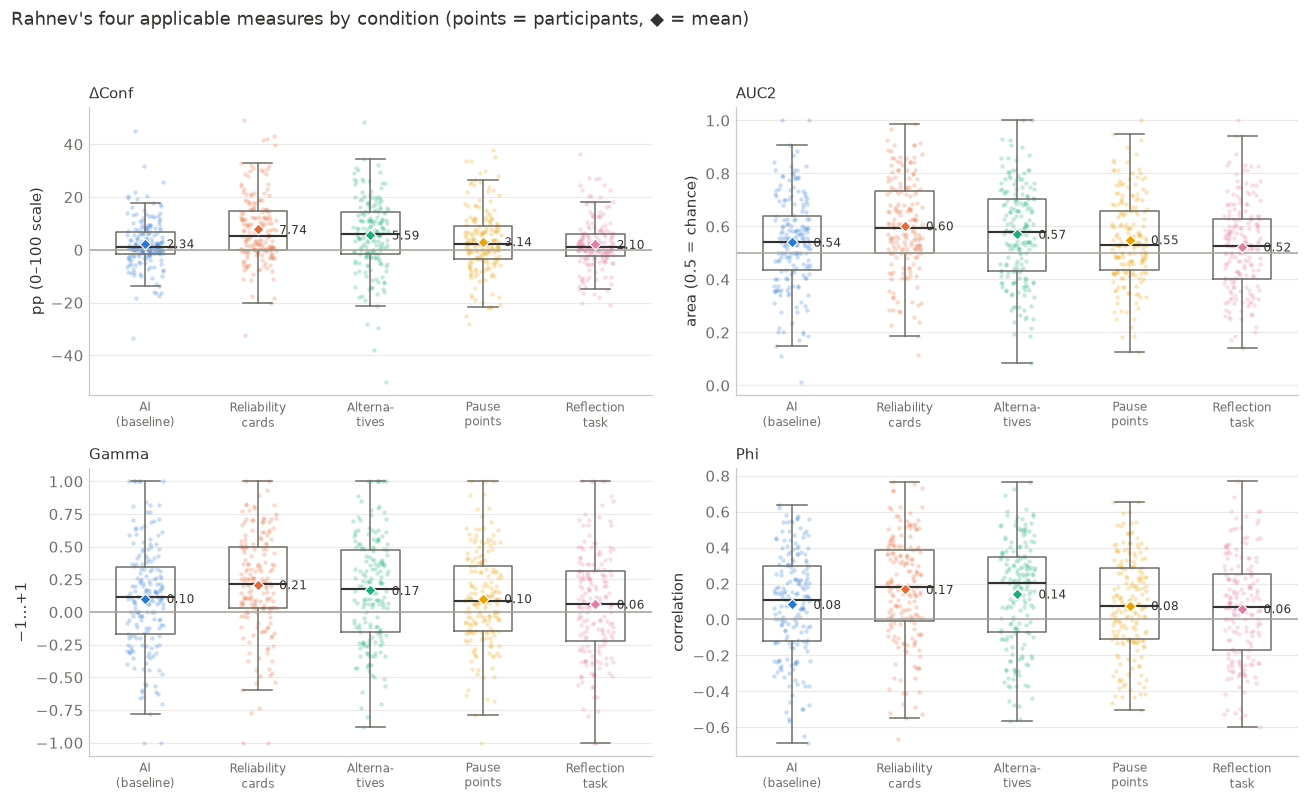

In [12]:
def condition_panel(ax, frame, outcome, title, ylabel=""):
    rng_j = np.random.default_rng(7)
    for i, condition in enumerate(CONDITIONS):
        values = frame.loc[frame["condition"] == condition, outcome].dropna().to_numpy(float)
        if not len(values):
            continue
        color = CONDITION_COLORS[condition]
        ax.scatter(i + rng_j.uniform(-0.16, 0.16, len(values)), values,
                   s=8, color=color, alpha=0.25, linewidths=0, zorder=1)
        ax.boxplot([values], positions=[i], widths=0.52, showfliers=False, zorder=2,
                   medianprops={"color": "#33322e", "linewidth": 1.4},
                   boxprops={"color": "#6f6d66", "linewidth": 1},
                   whiskerprops={"color": "#6f6d66", "linewidth": 1},
                   capprops={"color": "#6f6d66", "linewidth": 1})
        mean = values.mean()
        ax.scatter([i], [mean], marker="D", s=26, color=color,
                   edgecolor="white", linewidth=0.8, zorder=3)
        ax.annotate(f"{mean:.2f}", (i, mean), textcoords="offset points", xytext=(14, -3),
                    fontsize=8, color="#33322e")
    ax.set_xticks(range(len(CONDITIONS)))
    ax.set_xticklabels([TICK_LABELS[c] for c in CONDITIONS], fontsize=8)
    ax.set_title(title, fontsize=10, loc="left")
    ax.set_ylabel(ylabel)
    style_ax(ax)


MEASURE_UNITS = {"delta_conf": "pp (0–100 scale)", "auc2": "area (0.5 = chance)",
                 "gamma": "−1…+1", "phi": "correlation"}
fig, axes = plt.subplots(2, 2, figsize=(12, 7.4))
for ax, name in zip(axes.flat, TRADITIONAL):
    condition_panel(ax, measures, name, MEASURE_LABELS[name], MEASURE_UNITS[name])
    if name == "auc2":
        ax.axhline(0.5, color="#a5a39d", linewidth=1)
    elif name in ("gamma", "phi", "delta_conf"):
        ax.axhline(0, color="#a5a39d", linewidth=1)
fig.suptitle("Rahnev's four applicable measures by condition (points = participants, ◆ = mean)",
             x=0.01, ha="left", fontsize=12)
fig.tight_layout(rect=(0, 0, 1, 0.95))
plt.show()

In [13]:
Z_CRIT = norm.ppf(0.975)


def hedges_g(x, y):
    nx, ny = len(x), len(y)
    pooled = ((nx - 1) * x.var(ddof=1) + (ny - 1) * y.var(ddof=1)) / (nx + ny - 2)
    if pooled <= 0:
        return math.nan, math.nan, math.nan
    g = (x.mean() - y.mean()) / math.sqrt(pooled) * (1 - 3 / (4 * (nx + ny) - 9))
    se = math.sqrt((nx + ny) / (nx * ny) + g * g / (2 * (nx + ny - 2)))
    return g, g - Z_CRIT * se, g + Z_CRIT * se


def holm(pvalues: pd.Series) -> pd.Series:
    adjusted = pd.Series(np.nan, index=pvalues.index, dtype=float)
    valid = pvalues.dropna()
    running = 0.0
    for rank, (idx, p) in enumerate(valid.sort_values().items()):
        running = max(running, min(1.0, (len(valid) - rank) * p))
        adjusted[idx] = running
    return adjusted


def fmt_p(p):
    return "–" if not math.isfinite(p) else ("< .001" if p < 0.001 else f"= {p:.3f}".replace("0.", "."))


test_rows = []
for name in TRADITIONAL:
    base = measures.loc[measures["condition"] == BASELINE, name].dropna().to_numpy(float)
    for condition in CONDITIONS:
        if condition == BASELINE:
            continue
        x = measures.loc[measures["condition"] == condition, name].dropna().to_numpy(float)
        test = stats.ttest_ind(x, base, equal_var=False)
        g, g_low, g_high = hedges_g(x, base)
        test_rows.append({"measure": MEASURE_LABELS[name], "condition": CONDITION_LABELS[condition],
                          "mean": x.mean(), "mean_baseline": base.mean(),
                          "p_two_sided": test.pvalue, "hedges_g": g,
                          "g_ci": f"[{g_low:+.2f}, {g_high:+.2f}]"})
tests = pd.DataFrame(test_rows)
tests["p_holm"] = tests.groupby("measure")["p_two_sided"].transform(holm)
tests["significant"] = tests["p_holm"] < ALPHA
pretty = tests.copy()
pretty[["mean", "mean_baseline", "hedges_g"]] = pretty[["mean", "mean_baseline", "hedges_g"]].round(3)
pretty["p_two_sided"] = pretty["p_two_sided"].map(fmt_p)
pretty["p_holm"] = pretty["p_holm"].map(fmt_p)
display(pretty.style.hide(axis="index"))

measure,condition,mean,mean_baseline,p_two_sided,hedges_g,g_ci,p_holm,significant
ΔConf,Reliability cards,7.735000,2.337000,< .001,0.497000,"[+0.29, +0.70]",< .001,True
ΔConf,Alternatives,5.590000,2.337000,= .007,0.283000,"[+0.08, +0.49]",= .022,True
ΔConf,Pause points,3.136000,2.337000,= .462,0.076000,"[-0.13, +0.28]",= .924,False
ΔConf,Reflection task,2.103000,2.337000,= .806,-0.026000,"[-0.23, +0.18]",= .924,False
AUC2,Reliability cards,0.603000,0.541000,< .001,0.359000,"[+0.15, +0.56]",= .002,True
AUC2,Alternatives,0.571000,0.541000,= .104,0.170000,"[-0.03, +0.37]",= .312,False
AUC2,Pause points,0.550000,0.541000,= .594,0.055000,"[-0.15, +0.26]",= .623,False
AUC2,Reflection task,0.523000,0.541000,= .311,-0.105000,"[-0.31, +0.10]",= .623,False
Gamma,Reliability cards,0.210000,0.104000,= .010,0.270000,"[+0.06, +0.48]",= .042,True
Gamma,Alternatives,0.166000,0.104000,= .146,0.153000,"[-0.05, +0.36]",= .439,False


### 9. The performance confound, and accuracy-adjusted condition effects

Rahnev (2025) shows traditional type-2 measures depend on type-1 performance (reproduced in
Section 5c). That matters here because the conditions **differ in accuracy** (pause-points
scores ~1 problem lower than baseline). The Ratio variants that fix this need an SDT model this
task does not support, so the regression analogue is used instead: measure ~ condition +
standardized actual score. If a condition effect on a type-2 measure survives adjustment, it is
not explained by the accuracy difference.

In [14]:
correlations = measures[[*TRADITIONAL, "actual_score"]].corr().round(2)
correlations.index = correlations.columns = [MEASURE_LABELS.get(c, "actual score")
                                             for c in correlations.columns]
print("Correlations among measures and with actual score (analysis sample, pairwise complete):")
display(correlations)

Correlations among measures and with actual score (analysis sample, pairwise complete):


,ΔConf,AUC2,Gamma,Phi,actual score
ΔConf,1.00,0.80,0.75,0.86,-0.04
AUC2,0.80,1.00,0.95,0.91,-0.04
Gamma,0.75,0.95,1.00,0.88,-0.07
Phi,0.86,0.91,0.88,1.00,-0.01
actual score,-0.04,-0.04,-0.07,-0.01,1.00


In [15]:
import statsmodels.formula.api as smf

model_frame = measures.assign(condition_str=measures["condition"].astype(str))
model_frame["score_z"] = ((model_frame["actual_score"] - model_frame["actual_score"].mean())
                          / model_frame["actual_score"].std())

adjusted_rows = []
for name in TRADITIONAL:
    unadj = smf.ols(f"{name} ~ C(condition_str, Treatment(reference='ai'))",
                    data=model_frame).fit()
    adj = smf.ols(f"{name} ~ C(condition_str, Treatment(reference='ai')) + score_z",
                  data=model_frame).fit()
    for condition in CONDITIONS:
        if condition == BASELINE:
            continue
        term = f"C(condition_str, Treatment(reference='ai'))[T.{condition}]"
        adjusted_rows.append({
            "measure": MEASURE_LABELS[name], "condition": CONDITION_LABELS[condition],
            "unadjusted_coef": round(unadj.params[term], 3),
            "unadjusted_p": fmt_p(unadj.pvalues[term]),
            "adjusted_coef": round(adj.params[term], 3),
            "adjusted_p": fmt_p(adj.pvalues[term]),
            "score_z_coef": round(adj.params["score_z"], 3),
        })
adjusted = pd.DataFrame(adjusted_rows)
print("Condition effects vs baseline, before and after adjusting for actual score:")
display(adjusted.style.hide(axis="index"))

Condition effects vs baseline, before and after adjusting for actual score:


measure,condition,unadjusted_coef,unadjusted_p,adjusted_coef,adjusted_p,score_z_coef
ΔConf,Reliability cards,5.398000,< .001,5.306000,< .001,-0.418000
ΔConf,Alternatives,3.254000,= .006,3.166000,= .008,-0.418000
ΔConf,Pause points,0.799000,= .498,0.544000,= .651,-0.418000
ΔConf,Reflection task,-0.234000,= .843,-0.245000,= .836,-0.418000
AUC2,Reliability cards,0.062000,< .001,0.061000,< .001,-0.005000
AUC2,Alternatives,0.030000,= .092,0.029000,= .106,-0.005000
AUC2,Pause points,0.009000,= .600,0.006000,= .743,-0.005000
AUC2,Reflection task,-0.018000,= .315,-0.018000,= .311,-0.005000
Gamma,Reliability cards,0.106000,= .010,0.100000,= .016,-0.026000
Gamma,Alternatives,0.062000,= .132,0.056000,= .175,-0.026000


### 10. Pooled (item-level) check

With 12 trials the per-participant measures are noisy (Section 5d), so as a robustness check
the measures are recomputed on all trials of a condition pooled together, with a participant
bootstrap (resampling participants, 2000 draws) for 95% CIs.

In [16]:
rng_boot = np.random.default_rng(RNG_SEED + 2)
pooled_rows = []
for condition in CONDITIONS:
    sub = eligible_trials[eligible_trials["condition"] == condition].dropna(
        subset=["correct", "confidence"])
    arrays = {pid: (g["correct"].to_numpy(float), g["confidence"].to_numpy(float))
              for pid, g in sub.groupby("participant_id", observed=True)}
    pids = np.array(list(arrays))
    for name in ("delta_conf", "auc2"):
        fn = TRADITIONAL[name]
        point = fn(sub["correct"].to_numpy(float), sub["confidence"].to_numpy(float))
        draws = []
        for _ in range(2000):
            sample = rng_boot.choice(pids, size=len(pids), replace=True)
            correct = np.concatenate([arrays[p][0] for p in sample])
            confidence = np.concatenate([arrays[p][1] for p in sample])
            draws.append(fn(correct, confidence))
        low, high = np.percentile(draws, [2.5, 97.5])
        pooled_rows.append({"measure": MEASURE_LABELS[name], "condition": CONDITION_LABELS[condition],
                            "pooled": round(point, 3), "ci_95": f"[{low:.3f}, {high:.3f}]"})
pooled = pd.DataFrame(pooled_rows)
display(pooled.pivot(index="condition", columns="measure", values=["pooled", "ci_95"]))

pooled                  ci_95                
measure             AUC2  ΔConf            AUC2           ΔConf
condition                                                      
AI (baseline)      0.516  1.715  [0.493, 0.539]  [0.065, 3.360]
Alternatives       0.565  6.033  [0.543, 0.588]  [3.765, 8.247]
Pause points       0.549  5.197  [0.523, 0.576]  [2.522, 7.917]
Reflection task    0.515  1.948  [0.489, 0.538]  [0.159, 3.844]
Reliability cards  0.573  6.641  [0.548, 0.598]  [4.593, 8.771]

### 11. Summary and export

In [17]:
summary_lines = [
    f"Of Rahnev's (2025) 17 measures: 4 are computable on this dataset "
    f"(ΔConf, AUC2, Gamma, Phi), 13 require an SDT stimulus structure and trial counts this "
    f"task does not have (implemented and validated on simulation in Part 2 instead).", ""]
for name in TRADITIONAL:
    block = tests[tests["measure"] == MEASURE_LABELS[name]]
    significant = block.loc[block["significant"], "condition"].tolist()
    summary_lines.append(
        f"{MEASURE_LABELS[name]:6s} baseline mean {block['mean_baseline'].iloc[0]:.3f}; "
        f"Holm-significant differences vs baseline: {', '.join(significant) if significant else 'none'}")
adj_block = adjusted[(adjusted["measure"] == "ΔConf")]
summary_lines += ["", "Accuracy adjustment (Section 9) — ΔConf condition effects "
                  "unadjusted → adjusted:"]
for _, row in adj_block.iterrows():
    summary_lines.append(f"  {row['condition']:18s} {row['unadjusted_coef']:+.2f} "
                         f"(p {row['unadjusted_p']}) → {row['adjusted_coef']:+.2f} "
                         f"(p {row['adjusted_p']})")
print("\n".join(summary_lines))

Of Rahnev's (2025) 17 measures: 4 are computable on this dataset (ΔConf, AUC2, Gamma, Phi), 13 require an SDT stimulus structure and trial counts this task does not have (implemented and validated on simulation in Part 2 instead).

ΔConf  baseline mean 2.337; Holm-significant differences vs baseline: Reliability cards, Alternatives
AUC2   baseline mean 0.541; Holm-significant differences vs baseline: Reliability cards
Gamma  baseline mean 0.104; Holm-significant differences vs baseline: Reliability cards
Phi    baseline mean 0.084; Holm-significant differences vs baseline: Reliability cards

Accuracy adjustment (Section 9) — ΔConf condition effects unadjusted → adjusted:
  Reliability cards  +5.40 (p < .001) → +5.31 (p < .001)
  Alternatives       +3.25 (p = .006) → +3.17 (p = .008)
  Pause points       +0.80 (p = .498) → +0.54 (p = .651)
  Reflection task    -0.23 (p = .843) → -0.24 (p = .836)


In [18]:
OUTPUT_DIR = Path("notebook_analysis_output")
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)
measures.to_csv(OUTPUT_DIR / "rahnev_measures_per_participant.csv", index=False)
tests.to_csv(OUTPUT_DIR / "rahnev_measures_condition_tests.csv", index=False)
adjusted.to_csv(OUTPUT_DIR / "rahnev_measures_accuracy_adjusted.csv", index=False)
for path in sorted(OUTPUT_DIR.glob("rahnev_*.csv")):
    print(f"{path}  ({path.stat().st_size / 1e3:.0f} kB)")

notebook_analysis_output/rahnev_measures_accuracy_adjusted.csv  (1 kB)
notebook_analysis_output/rahnev_measures_condition_tests.csv  (2 kB)
notebook_analysis_output/rahnev_measures_per_participant.csv  (101 kB)
